In [1]:
import pandas as pd
import matplotlib as plt

In [2]:
train_df = pd.read_csv("../data/processed/train_transactions.csv",parse_dates=["InvoiceDate"])

train_explore = train_df.copy()

In [3]:
train_explore.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [37]:
train_explore.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334054 entries, 0 to 334053
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    334054 non-null  object        
 1   StockCode    334054 non-null  object        
 2   Description  332872 non-null  object        
 3   Quantity     334054 non-null  int64         
 4   InvoiceDate  334054 non-null  datetime64[ns]
 5   UnitPrice    334054 non-null  float64       
 6   CustomerID   242127 non-null  float64       
 7   Country      334054 non-null  object        
 8   day_of_week  334054 non-null  object        
 9   hour         334054 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(5)
memory usage: 24.2+ MB


In [4]:
train_explore.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,334054.000000,334054,334054.000000,242127.000000
mean,9.659142,2011-04-21 18:35:55.838397440,4.857252,15275.430270
min,-74215.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-02-07 12:05:00,1.250000,13859.000000
50%,3.000000,2011-04-21 16:59:00,2.100000,15144.000000
75%,10.000000,2011-07-05 15:31:00,4.130000,16807.000000
max,74215.000000,2011-09-09 17:52:00,38970.000000,18287.000000
std,190.555018,NaN,111.150897,1726.435465


<Axes: xlabel='InvoiceDate'>

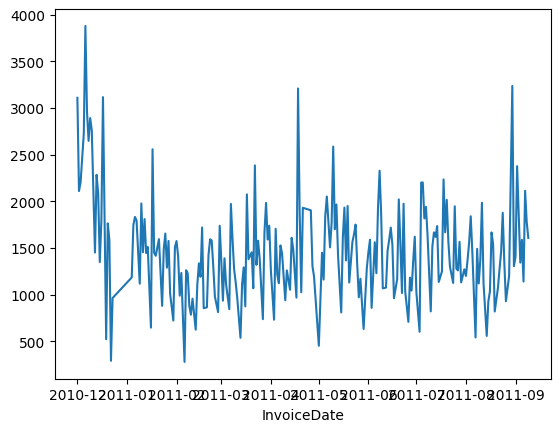

In [5]:
train_explore["InvoiceDate"].dt.date.value_counts().sort_index().plot()

<Axes: xlabel='InvoiceDate'>

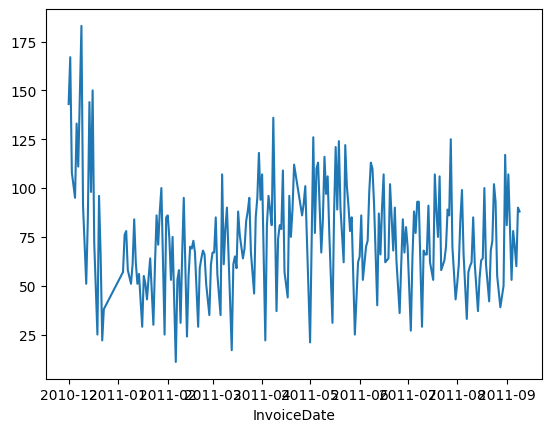

In [6]:
train_explore.groupby(train_explore["InvoiceDate"].dt.date)["InvoiceNo"].nunique().plot()

<Axes: xlabel='InvoiceDate'>

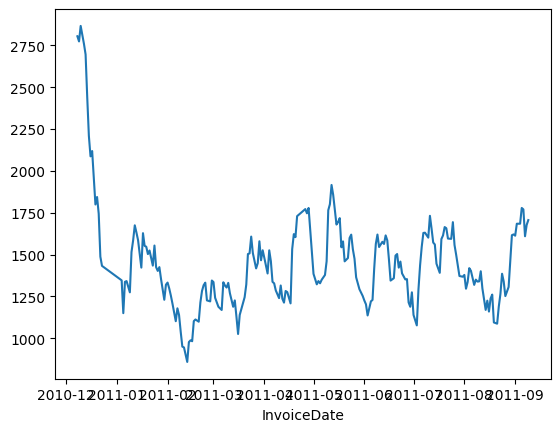

In [7]:
daily_counts = train_explore["InvoiceDate"].dt.date.value_counts().sort_index()

daily_counts.rolling(7).mean().plot()

<Axes: xlabel='InvoiceDate'>

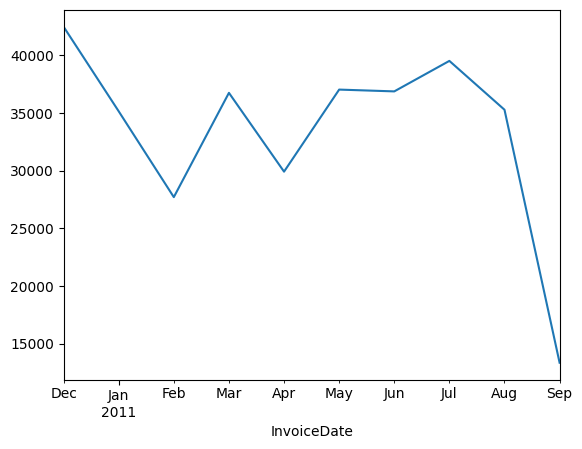

In [8]:
train_explore["InvoiceDate"].dt.to_period("M").value_counts().sort_index().plot()

<Axes: xlabel='day_of_week'>

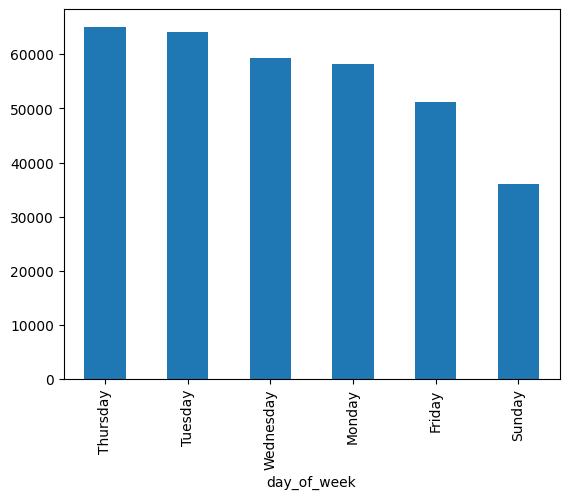

In [9]:
train_explore["day_of_week"] = train_explore["InvoiceDate"].dt.day_name()

train_explore["day_of_week"].value_counts().plot(kind="bar")

<Axes: >

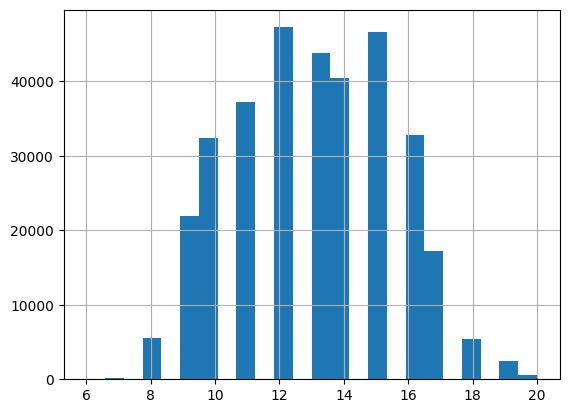

In [10]:
train_explore["hour"] = train_explore["InvoiceDate"].dt.hour

train_explore["hour"].hist(bins=24)

<Axes: >

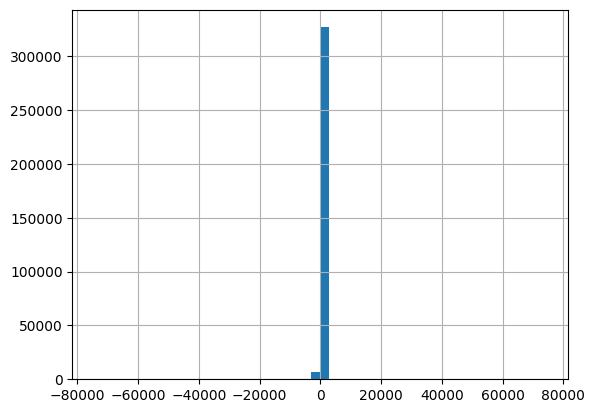

In [11]:
train_explore["Quantity"].hist(bins=50)

<Axes: >

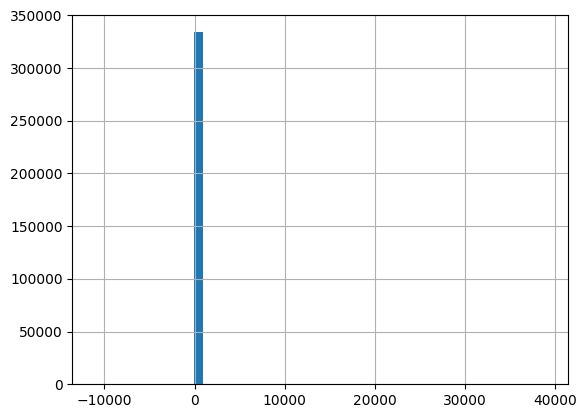

In [12]:
train_explore["UnitPrice"].hist(bins=50)

<Axes: >

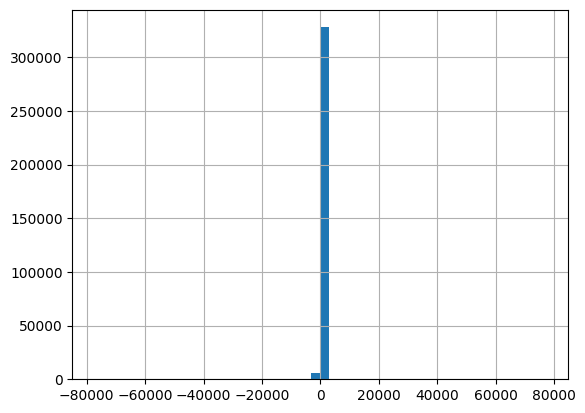

In [13]:
(train_explore["Quantity"] * train_explore["UnitPrice"]).hist(bins=50)

<Axes: >

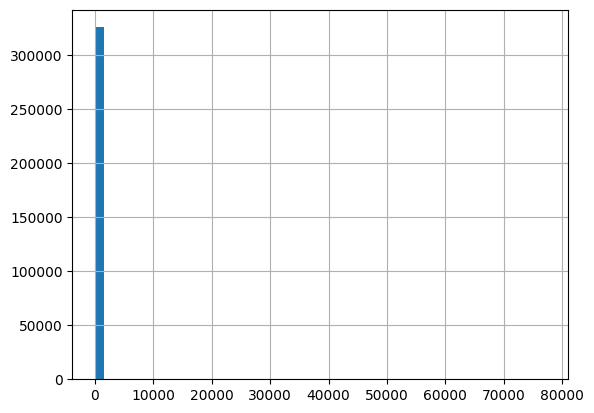

In [14]:
revenue = train_explore["Quantity"] * train_explore["UnitPrice"]

revenue[revenue > 0].hist(bins=50)

<Axes: >

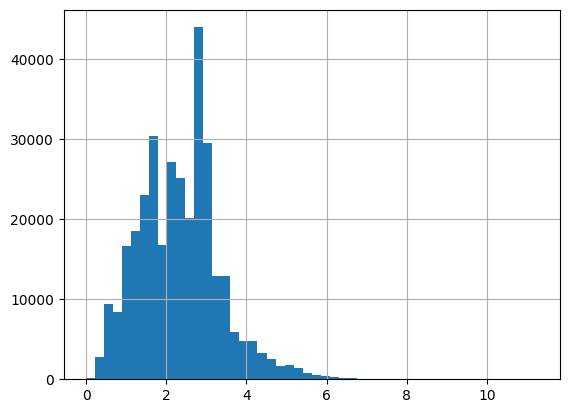

In [15]:
import numpy as np

np.log1p(revenue[revenue > 0]).hist(bins=50)

In [16]:
revenue.groupby(train_explore["Country"]).sum().sort_values(ascending=False).head(10)

Country
United Kingdom    4975837.682
EIRE               182847.540
Netherlands        181564.840
Germany            144316.210
France             120566.810
Australia          111178.440
Spain               37279.230
Switzerland         32179.450
Belgium             25142.700
Japan               24937.350
dtype: float64

In [17]:
train_explore.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)


Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     36802
JUMBO BAG RED RETROSPOT               32406
PACK OF 72 RETROSPOT CAKE CASES       28581
WHITE HANGING HEART T-LIGHT HOLDER    26067
ASSORTED COLOUR BIRD ORNAMENT         24589
ASSORTED COLOURS SILK FAN             20967
PACK OF 12 LONDON TISSUES             20087
SMALL POPCORN HOLDER                  20068
PACK OF 60 PINK PAISLEY CAKE CASES    19937
MINI PAINT SET VINTAGE                17981
Name: Quantity, dtype: int64

In [18]:
revenue.groupby(train_explore["Description"]).sum().sort_values(ascending=False).head(10)

Description
REGENCY CAKESTAND 3 TIER              126479.19
DOTCOM POSTAGE                        120411.00
PARTY BUNTING                          85663.60
WHITE HANGING HEART T-LIGHT HOLDER     73035.45
JUMBO BAG RED RETROSPOT                62783.81
POSTAGE                                42445.43
ASSORTED COLOUR BIRD ORNAMENT          39728.53
PICNIC BASKET WICKER 60 PIECES         39619.50
CHILLI LIGHTS                          32511.67
SPOTTY BUNTING                         30246.85
dtype: float64

In [19]:
train_explore.groupby("CustomerID")["Quantity"].sum().sort_values(ascending=False).head(10)

CustomerID
14646.0    127548
12415.0     66474
14156.0     48057
14298.0     47694
13694.0     47517
14911.0     40760
17511.0     40168
17450.0     32171
18102.0     31471
15311.0     29100
Name: Quantity, dtype: int64

In [20]:
train_explore.groupby("CustomerID")["InvoiceNo"].nunique().sort_values(ascending=False).head(10)

CustomerID
12748.0    139
14911.0    138
17841.0    112
14606.0     98
13089.0     90
15311.0     86
12971.0     67
14527.0     63
16422.0     62
16029.0     60
Name: InvoiceNo, dtype: int64

In [21]:
train_explore["CustomerID"].isna().sum()

np.int64(91927)

In [22]:
train_explore[train_explore["UnitPrice"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,day_of_week,hour
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,Friday,14
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,Friday,14


In [23]:
train_explore[train_explore["Quantity"] == 80995]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,day_of_week,hour


In [24]:
future_df = pd.read_csv("../data/processed/future_transactions.csv",parse_dates=["InvoiceDate"])

future_explore = future_df.copy()

In [25]:
future_explore[future_explore["Quantity"]==80995]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
206367,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom


In [26]:
train_explore[train_explore["InvoiceNo"].astype(str).str.startswith("C")].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,day_of_week,hour
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,Wednesday,9
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,Wednesday,9
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,Wednesday,10
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,Wednesday,10
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,Wednesday,10


In [27]:
train_explore["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(6031)

In [28]:
train_explore[train_explore["InvoiceNo"].astype(str).str.startswith("C")]["Quantity"].head()

141    -1
154    -1
235   -12
236   -24
237   -24
Name: Quantity, dtype: int64

In [29]:
train_explore["CustomerID"].isna().mean()

np.float64(0.27518604776473266)

<Axes: >

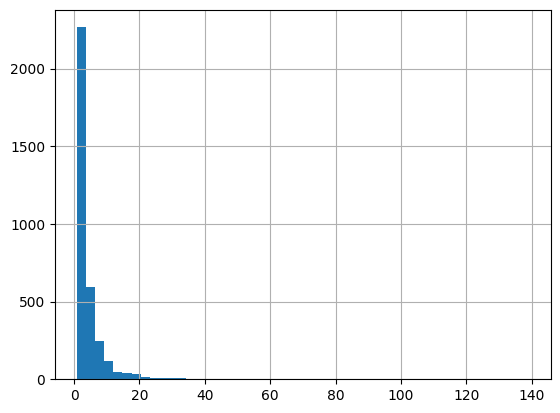

In [30]:
orders_per_customer = train_explore.groupby("CustomerID")["InvoiceNo"].nunique()

orders_per_customer.hist(bins=50)

C:\Users\PC\AppData\Local\Temp\ipykernel_7468\356584035.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  customer_revenue = train_explore.groupby("CustomerID").apply(


<Axes: >

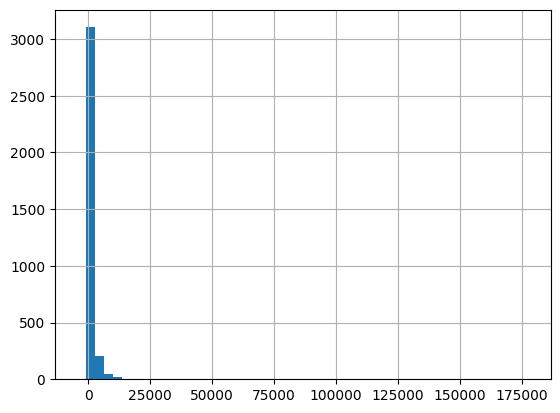

In [31]:
revenue = train_explore["Quantity"] * train_explore["UnitPrice"]

customer_revenue = train_explore.groupby("CustomerID").apply(
    lambda x: (x["Quantity"] * x["UnitPrice"]).sum()
)

customer_revenue.hist(bins=50)

<Axes: xlabel='Description'>

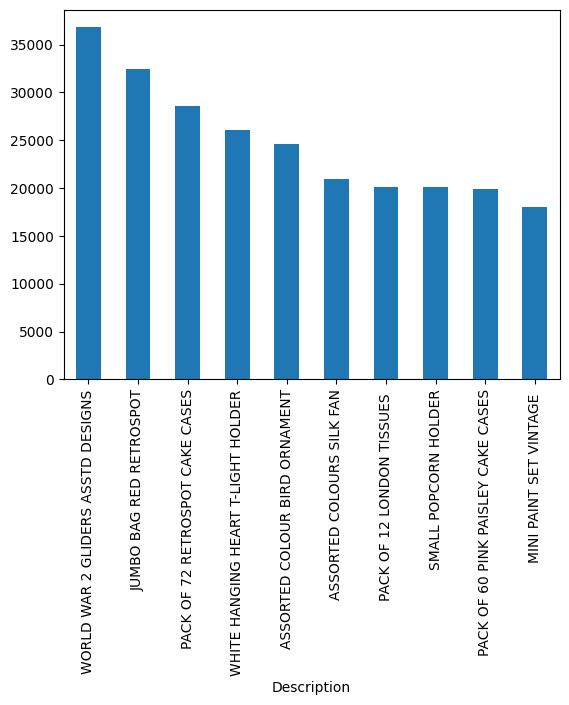

In [32]:
top_products = (
    train_explore.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products.plot(kind="bar")

<Axes: xlabel='InvoiceDate'>

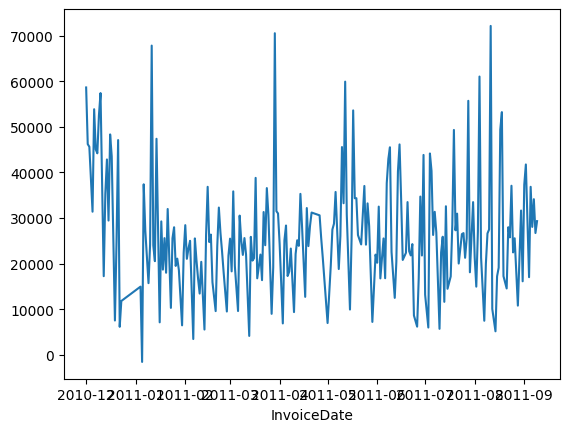

In [33]:
revenue = train_explore["Quantity"] * train_explore["UnitPrice"]

daily_revenue = revenue.groupby(train_explore["InvoiceDate"].dt.date).sum()

daily_revenue.plot()

look for correlations

In [34]:
corr_matrix = train_explore.corr(numeric_only=True)

In [35]:
corr_matrix

,Quantity,UnitPrice,CustomerID,hour
Quantity,1.000000,-0.001365,-0.005629,-0.012224
UnitPrice,-0.001365,1.000000,-0.002015,0.001688
CustomerID,-0.005629,-0.002015,1.000000,0.070041
hour,-0.012224,0.001688,0.070041,1.000000
